In [ ]:
import pandas as pd 
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import json
import seaborn as sns
import geopandas as gpd
import matplotlib.cm as cm
from keplergl import KeplerGl

In [440]:
data_dir = Path("../OptimizationInput")
base_load_df = pd.read_csv(data_dir / "alamedaBaseLoadDf_slice_month6_hour20.csv")
feeder_capacity_df = pd.read_csv(data_dir / "alamedaMinICA_slice_month6_hour20.csv")
# ev_load_df = pd.read_csv(data_dir / "ev_load_growth_from2025unmanaged_to2035managed_slice_hour_20.csv", dtype={"geoid": str})
ev_load_df = pd.read_csv(data_dir / "ev_load_growth_from2025unmanaged_to2035managed_max_slice_hour_20.csv", dtype={"geoid": str})
feeder_block_map_df = pd.read_csv(data_dir / "feederBlockIntersectionMtx.csv")
ev_network_df = pd.read_parquet(Path("../data/network_analysis/network_df.parquet"))
census_blocks = gpd.read_file('/Users/lazlopaul/Desktop/sys_ms/mobility/final-project/OptimalChargerPlacement/data/Geography_Files/location_str_to_geoid_mapping.shp')

# Assessing Overload

In [441]:
# Can use origin demand, assuming people charge before their next destination
# If I were to use destination demand, I would have to get it from the neighbors
ev_network_df['total_ev_load'] = ev_network_df['origin_demand_(kW)'] # + ev_network_df['destination_demand_(kW)']

In [442]:
total_ev_load_series = ev_network_df.set_index('geoid')['total_ev_load'].drop_duplicates()

In [443]:
# Trying with ev load from DF
feeder_loads = {}
for row in feeder_block_map_df.iterrows():
    feeder_loads[row[0]] = 0
    for block, proportion in row[1].items():
        # feeder_loads[row[0]] += proportion * ev_load_df.loc[ev_load_df['geoid'] == block, 'load'].values[0]
        feeder_loads[row[0]] += proportion * ev_network_df.loc[ev_network_df['geoid'] == block, 'total_ev_load'].values[0]

In [444]:
feeder_ev_load_series = pd.Series(feeder_loads)
feeder_ev_load_series = feeder_ev_load_series.rename('ev_load')

In [445]:
# Targeting 50% feeder overload based on Alan Jenn Paper, need to increase ev_load_df calculation by 4.7x
# feeder_ev_load_increased_series = feeder_ev_load_series.rename('ev_load') * 4.7
# feeder_ev_aggregated_df = feeder_capacity_df.merge(feeder_ev_load_increased_series, left_index=True, right_index=True)
# feeder_ev_aggregated_df[['IC_min_kW', 'ev_load']].plot()

<Axes: >

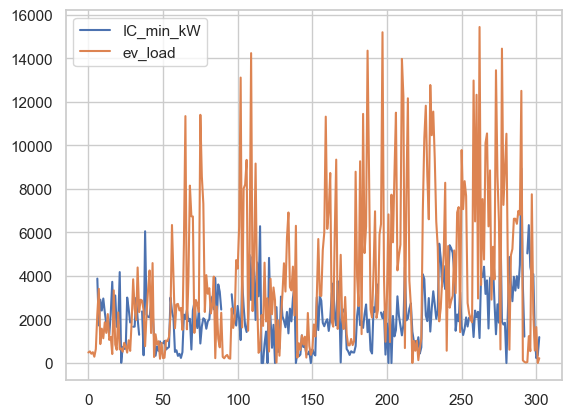

In [446]:
feeder_ev_aggregated_df = feeder_capacity_df.merge(feeder_ev_load_series, left_index=True, right_index=True)
feeder_ev_aggregated_df[['IC_min_kW', 'ev_load']].plot()

/var/folders/ff/05grcg517lbgzyz6gz1m5x2c0000gq/T/ipykernel_79658/458347633.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


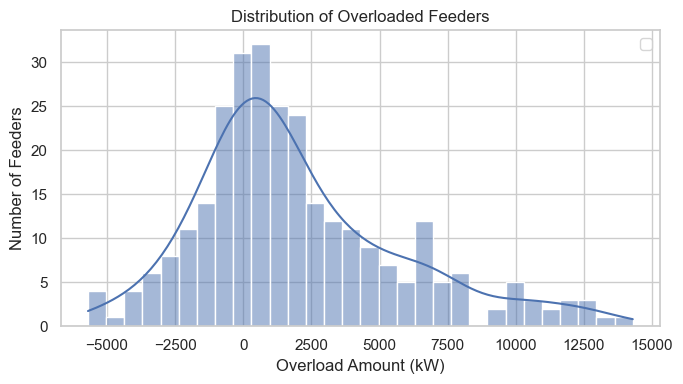

In [447]:
plt.figure(figsize=(7, 4))
sns.histplot(feeder_ev_aggregated_df['ev_load'] - feeder_ev_aggregated_df['IC_min_kW'], bins=30, kde=True)
plt.title('Distribution of Overloaded Feeders')
plt.xlabel('Overload Amount (kW)')
plt.ylabel('Number of Feeders')
plt.legend()
plt.tight_layout()
plt.show()

In [448]:
((feeder_ev_aggregated_df['ev_load'] > feeder_ev_aggregated_df['IC_min_kW']).sum() / len(feeder_ev_aggregated_df)) * 100
# 6% feeders are overloaded with EV adoption

np.float64(65.01650165016501)

In [617]:
# feeder_disagg_df = feeder_block_map_df.div(feeder_block_map_df.sum(axis=1), axis=0)

In [618]:
df_lst = []
for (i,row) in feeder_block_map_df.iterrows():
    feeder_block_df = census_blocks.set_index('GEOID').merge(pd.DataFrame(row), left_index=True, right_index=True)
    feeder_total_area = feeder_block_df['geometry'].to_crs(epsg=3857).area.sum()
    feeder_block_df['area_proportion'] = feeder_block_df['geometry'].to_crs(epsg=3857).area / feeder_total_area
    feeder_block_df['proportion'] = row.values / row.values.sum()
    df_lst.append(feeder_block_df['proportion'].rename(i))
feeder_disagg_df = pd.concat(df_lst, axis=1).T

In [619]:
capacity_by_block = {}
base_load_by_block = {}

for block in feeder_disagg_df.columns:
    # Multiply proportion by capacity for each feeder, then sum
    capacity_by_block[block] = (feeder_disagg_df[block] * feeder_capacity_df['IC_min_kW']).sum()
    base_load_by_block[block] = (feeder_disagg_df[block] * base_load_df['high_load_kw']).sum()

# Convert to a Series or DataFrame
capacity_series = pd.Series(capacity_by_block)
base_load_series = pd.Series(base_load_by_block)

In [620]:
df = ev_network_df.merge(capacity_series.rename("IC_min_kW"), how="left", left_on="geoid", right_index=True).merge(base_load_series.rename("base_load_kW"), how="left", left_on="geoid", right_index=True)
# df = df.merge(ev_load_df[['geoid_str', 'load']], how="left", left_on="geoid_str_", right_on="geoid_str")

In [621]:
df['overload'] = -1 * (df['IC_min_kW'] - df['total_ev_load'])

In [622]:
gdf = census_blocks.merge(df, left_on='GEOID', right_on='geoid', how='right', suffixes=('', '_y'))


<Axes: >

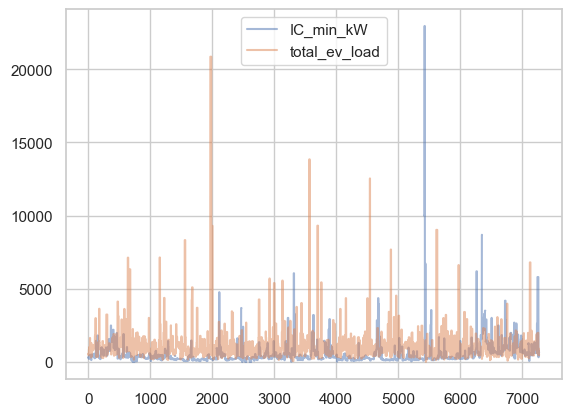

In [623]:
df[['IC_min_kW', 'total_ev_load']].plot(alpha=0.5)

In [624]:
def impute_load_data(df, column: str):
    # Step 1: Get rows with valid (non-zero, non-NaN) values
    valid_data = df[(df[column] > 0) & (df[column].notna())].copy()
    
    # Calculate the ratio of baseload to EV load
    valid_data['baseload_to_ev_ratio'] = (
        valid_data[column] / valid_data['total_ev_load']
    )
    
    # Step 2: Create bins for all rows based on total EV load
    df['ev_load_bin'] = pd.qcut(
        df['total_ev_load'], 
        q=10,
        labels=False, 
        duplicates='drop'
    )
    
    # Step 3: Calculate bin statistics from valid data
    bin_stats = valid_data.groupby(
        pd.qcut(valid_data['total_ev_load'], q=10, labels=False, duplicates='drop')
    )['baseload_to_ev_ratio'].agg(['mean', 'std', 'median'])
    
    # Step 4: Impute missing or zero values
    def impute_baseload(row):
        # Check if value is missing or zero
        if pd.isna(row[column]) or row[column] == 0:
            bin_idx = row['ev_load_bin']
            
            if bin_idx in bin_stats.index:
                # Sample from normal distribution using bin statistics
                ratio = np.random.normal(
                    bin_stats.loc[bin_idx, 'mean'],
                    bin_stats.loc[bin_idx, 'std']
                )
                # Ensure ratio is positive
                ratio = max(ratio, 0)
                return ratio * row['total_ev_load']
            else:
                # Fallback to overall median if bin not found
                return bin_stats['median'].median() * row['total_ev_load']
        else:
            return row[column]
    
    df[column] = df.apply(impute_baseload, axis=1)
    
    # Clean up temporary column
    df.drop('ev_load_bin', axis=1, inplace=True)

# Apply the function
impute_load_data(df, 'base_load_kW')
impute_load_data(df, 'IC_min_kW')

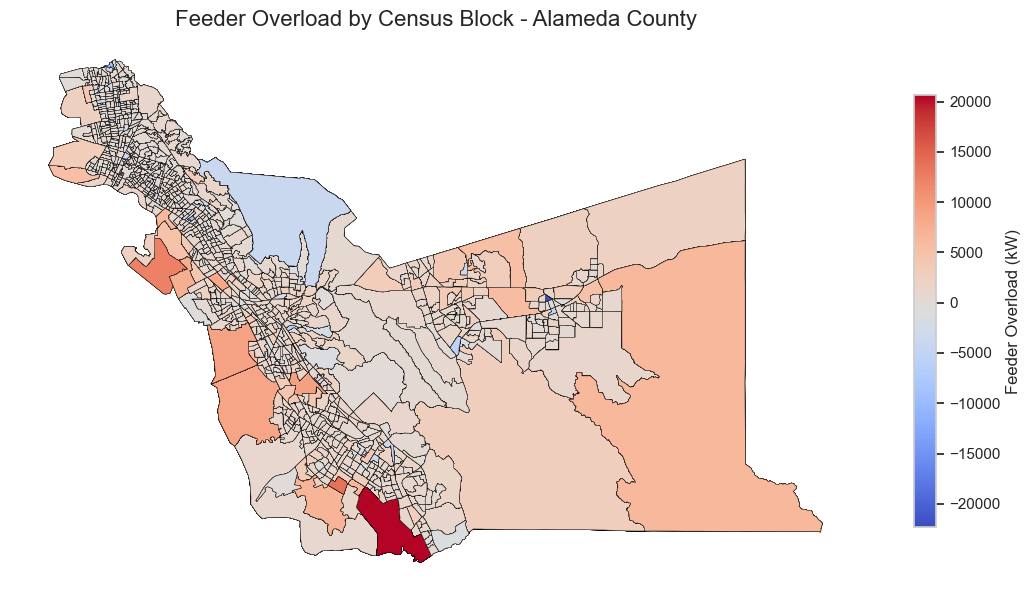

In [636]:
# # Merge with your capacity data
# blocks_unique = df.groupby('geoid').agg({
#     'overload': 'first'
# }).reset_index()

# # Merge on GEOID
# census_blocks_plotting = census_blocks.merge(
#     blocks_unique, 
#     left_on='GEOID', 
#     right_on='geoid', 
#     how='left'
# )

# Plot
fig, ax = plt.subplots(figsize=(11, 9))

gdf.plot(
    ax=ax,
    column='overload',
    # cmap='YlOrRd',
    cmap='coolwarm',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': 'Feeder Overload (kW)',
        'orientation': 'vertical',
        'shrink': 0.5
    }
)

plt.title('Feeder Overload by Census Block - Alameda County', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

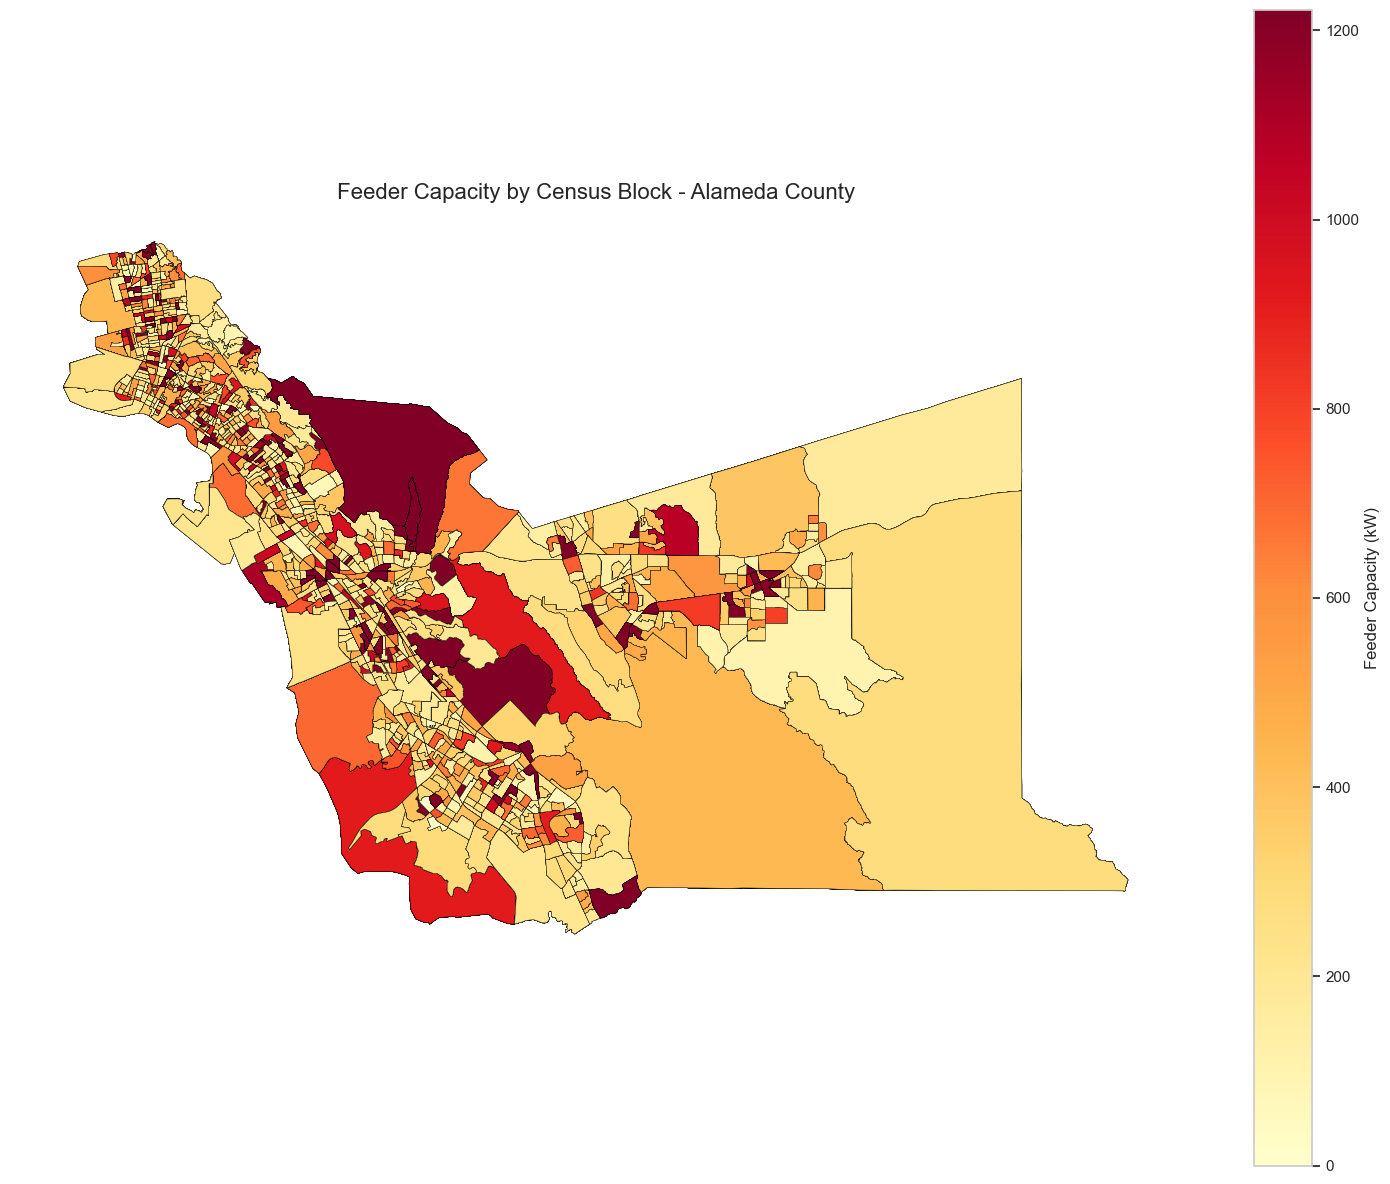

In [638]:
# Plot
fig, ax = plt.subplots(figsize=(15, 12))

# # Merge with your capacity data
# blocks_unique = df.groupby('geoid').agg({
#     'IC_min_kW': 'first'
# }).reset_index()

# # Merge on GEOID
# census_blocks_plotting = census_blocks.merge(
#     blocks_unique, 
#     left_on='GEOID', 
#     right_on='geoid', 
#     how='left'
# )


Q1 = gdf['IC_min_kW'].quantile(0.25)
Q3 = gdf['IC_min_kW'].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
gdf_filtered = gdf.copy()
gdf_filtered['IC_min_kW'] = gdf_filtered['IC_min_kW'].clip(lower=lower_bound, upper=upper_bound)

gdf_filtered.plot(
    ax=ax,
    column='IC_min_kW',
    cmap='YlOrRd',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': 'Feeder Capacity (kW)',
        'orientation': 'vertical'
    }
)
plt.title('Feeder Capacity by Census Block - Alameda County', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Allocating feeder capacity to census blocks - EV site scoring

In [640]:
# Calculate the sum of distances for each geoid
distance_sum = gdf.groupby('GEOID')['distance_km'].sum().reset_index()

# Rename the summed column for clarity
distance_sum.rename(columns={'distance_km': 'total_distance_to_neighbors_km'}, inplace=True)

# Merge this sum back into the original DataFrame
gdf = pd.merge(gdf, distance_sum, on='GEOID', how='left')

In [641]:
# First, calculate the degree (number of neighbors) for each geoid
degree_df = gdf.groupby('geoid').size().reset_index(name='degree')

# Merge degree back to main dataframe
gdf = gdf.merge(degree_df, on='geoid', how='left', suffixes=('', '_y'))

# Calculate the new metric
max_overload = gdf['overload'].max()

# converting kW to MW by dividing by 10^3

gdf['transfer_metric'] = ( max_overload - (gdf['overload'] / (gdf['degree'] * gdf['distance_km']))) / 10**3 
# gdf['transfer_metric'] = ( (gdf['overload'] * gdf['total_distance_to_neighbors_km'] / (gdf['degree'] * gdf['distance_km']))) / 10**3 
# gdf['transfer_metric'] = gdf['transfer_metric'].max() - gdf['transfer_metric']
gdf = gdf.dropna(subset=['transfer_metric'])

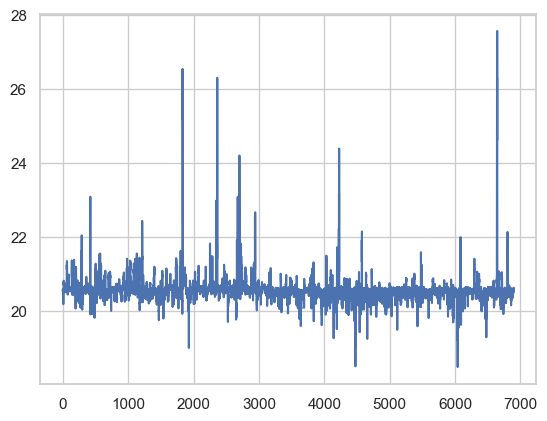

In [642]:
plt.plot(gdf.sort_values(by = 'geoid')['transfer_metric'].values)

In [643]:
# Build graph with normalized weights
# increasing weights to MW
G = nx.Graph()
for _, row in gdf.iterrows():
    G.add_edge(
        row['geoid'],
        row['neighbor_geoid'],
        weight=row['transfer_metric']
    )

# Calculate closeness centrality
closeness = nx.closeness_centrality(G, distance='weight', wf_improved=True)

# Convert to dataframe
closeness_centrality_df = pd.DataFrame(list(closeness.items()), 
                            columns=['geoid', 'closeness_centrality'])

In [644]:
gdf = gdf.merge(
    closeness_centrality_df,
    left_on='GEOID',
    right_on='geoid',
    how='left',
    suffixes=('', '_y')
)

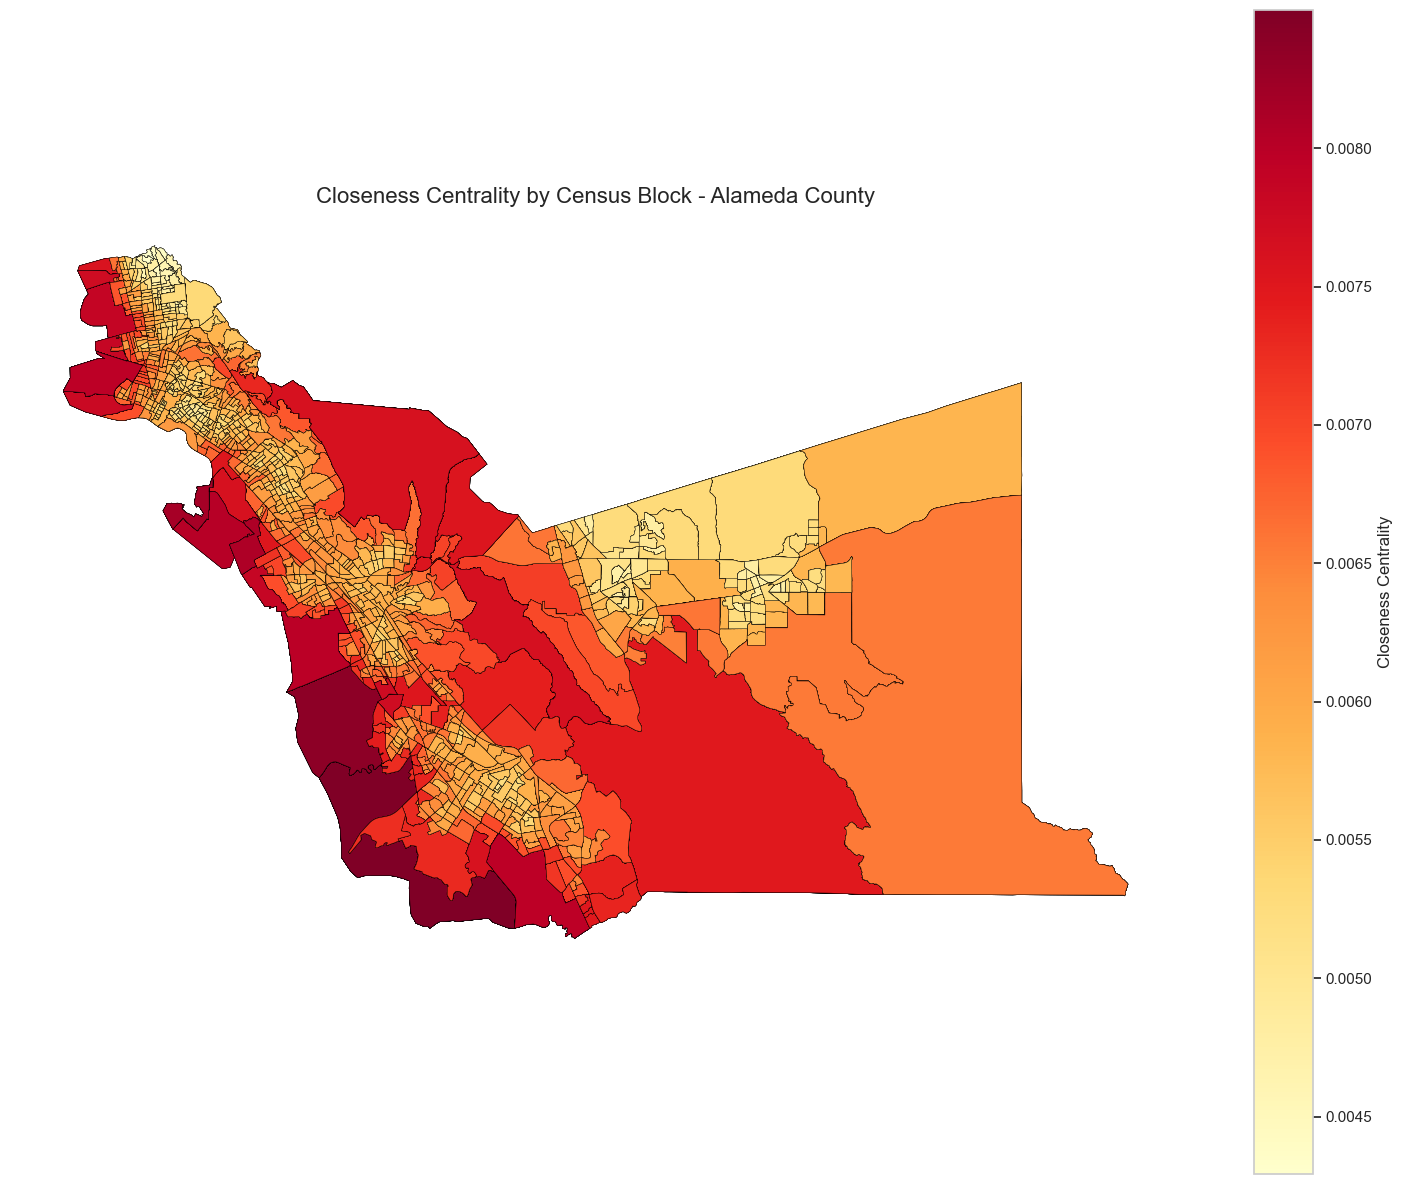

Centrality Statistics:
Mean: 0.0060
Median: 0.0059
Min: 0.0043
Max: 0.0089

Top 20 most central blocks:
             geoid  closeness_centrality
397   060019900000              0.008925
396   060014415034              0.008500
398   060014371011              0.008381
1039  060014283014              0.008168
425   060014324003              0.008103
1040  060014090002              0.008011
511   060014371014              0.007978
254   060014017003              0.007963
406   060014415032              0.007960
3     060014220001              0.007863
485   060014251012              0.007858
499   060014334003              0.007853
395   060019819001              0.007779
908   060014384002              0.007745
962   060014403331              0.007743
481   060014204021              0.007734
140   060014351031              0.007639
182   060014090003              0.007620
87    060014301021              0.007616
407   060014446022              0.007603


In [645]:
fig, ax = plt.subplots(figsize=(15, 12))

gdf.plot(
    ax=ax,
    column='closeness_centrality',
    cmap='YlOrRd',  # or 'viridis', 'plasma', 'coolwarm'
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': 'Closeness Centrality',
        'orientation': 'vertical'
    }
)


plt.title('Closeness Centrality by Census Block - Alameda County', fontsize=16)
plt.axis('off')
plt.tight_layout()
plt.show()

# Optional: Print statistics
print(f"Centrality Statistics:")
print(f"Mean: {closeness_centrality_df['closeness_centrality'].mean():.4f}")
print(f"Median: {closeness_centrality_df['closeness_centrality'].median():.4f}")
print(f"Min: {closeness_centrality_df['closeness_centrality'].min():.4f}")
print(f"Max: {closeness_centrality_df['closeness_centrality'].max():.4f}")
print(f"\nTop 20 most central blocks:")
print(closeness_centrality_df.nlargest(20, 'closeness_centrality'))

In [646]:
# grid build score is ( - overload / centrality)
gdf['grid_build_score'] =  - gdf['overload'] * gdf['closeness_centrality'] # df['grid_build_score'] =  - df['overload'] / 10**3 /df['closeness_centrality']
# df = df.merge(
#     census_blocks,
#     left_on='geoid',
#     right_on='GEOID',
#     how='left'
# )

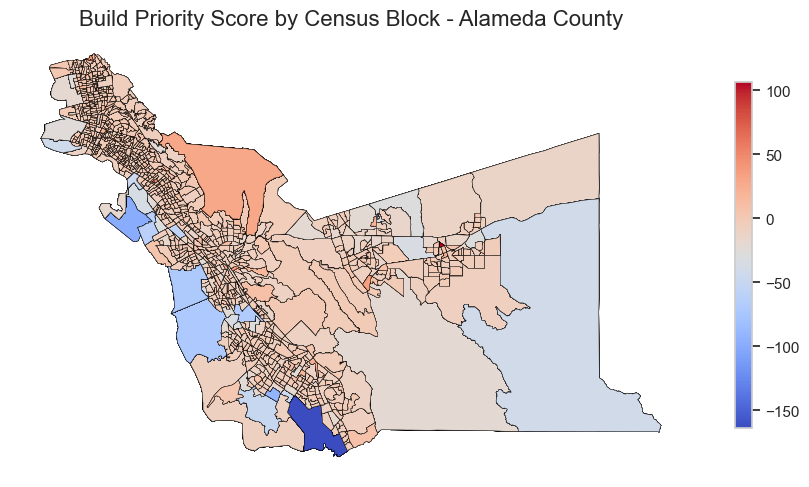

Centrality Statistics:
Mean: -4.5943
Median: -3.0134
Min: -164.3618
Max: 106.5985


In [671]:
fig, ax = plt.subplots(figsize=(11, 9))

gdf.plot(
    ax=ax,
    column='grid_build_score',
    # cmap='YlOrRd',  # or 'viridis', 'plasma', 'coolwarm'
    cmap = 'coolwarm',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'orientation': 'vertical',
        'shrink': 0.5
    }
)


plt.title('Build Priority Score by Census Block - Alameda County', fontsize=16)
plt.axis('off')
# plt.tight_layout()
plt.show()

# Optional: Print statistics
print(f"Centrality Statistics:")
print(f"Mean: {gdf['grid_build_score'].mean():.4f}")
print(f"Median: {gdf['grid_build_score'].median():.4f}")
print(f"Min: {gdf['grid_build_score'].min():.4f}")
print(f"Max: {gdf['grid_build_score'].max():.4f}")

In [649]:
gdf[['geoid', 'grid_build_score']].drop_duplicates().nlargest(20, 'grid_build_score').to_csv('top_20_build_priority_blocks.csv', index=False)

In [650]:
print(f"\nTop 20 most prioritized for building:")
print(gdf[['geoid', 'grid_build_score']].drop_duplicates().nlargest(20, 'grid_build_score'))


Top 20 most prioritized for building:
             geoid  grid_build_score
5124  060014514031        106.598518
5119  060014086003         49.168597
5136  060014364031         36.819092
6015  060014212004         36.385271
5932  060014506073         34.424025
6868  060014301021         29.041513
3112  060014516025         23.528608
4411  060014419281         22.374589
1988  060014501022         19.792350
6368  060014035012         18.893957
2313  060014229011         17.946472
3642  060014364022         16.515851
5230  060014083001         16.329792
4404  060014419272         16.264758
6058  060014363022         14.988981
6072  060014231001         14.435136
6019  060014004002         13.577417
3125  060014212001         12.857795
3034  060014059012         12.301932
331   060014507012         10.918162


In [651]:
print(f"\nTop 20 least overloaded blocks:")
print(gdf[['geoid', 'overload']].drop_duplicates().nsmallest(20, 'overload'))


Top 20 least overloaded blocks:
             geoid      overload
5124  060014514031 -22333.620933
5119  060014086003  -9247.269269
6015  060014212004  -8476.679285
5136  060014364031  -5957.418309
5932  060014506073  -5264.937486
3112  060014516025  -4916.784689
1988  060014501022  -3994.813031
6868  060014301021  -3813.434136
4411  060014419281  -3576.473969
2313  060014229011  -3349.449877
6368  060014035012  -3306.773027
3125  060014212001  -2918.231559
4404  060014419272  -2917.868544
5230  060014083001  -2700.564359
6058  060014363022  -2585.068106
3642  060014364022  -2459.326771
6019  060014004002  -2430.048050
6072  060014231001  -2362.320816
3034  060014059012  -2274.802137
2333  060014201003  -2144.809365


In [652]:
set(gdf[['geoid', 'overload']].drop_duplicates().nsmallest(10, 'overload').index).intersection(set(gdf[['geoid', 'grid_build_score']].drop_duplicates().nlargest(10, 'grid_build_score').index))

{1988, 3112, 4411, 5119, 5124, 5136, 5932, 6015, 6868}

In [653]:
set(gdf[['geoid', 'overload']].drop_duplicates().nsmallest(20, 'overload').index).intersection(set(gdf[['geoid', 'grid_build_score']].drop_duplicates().nlargest(20, 'grid_build_score').index))

{1988,
 2313,
 3034,
 3112,
 3125,
 3642,
 4404,
 4411,
 5119,
 5124,
 5136,
 5230,
 5932,
 6015,
 6019,
 6058,
 6072,
 6368,
 6868}

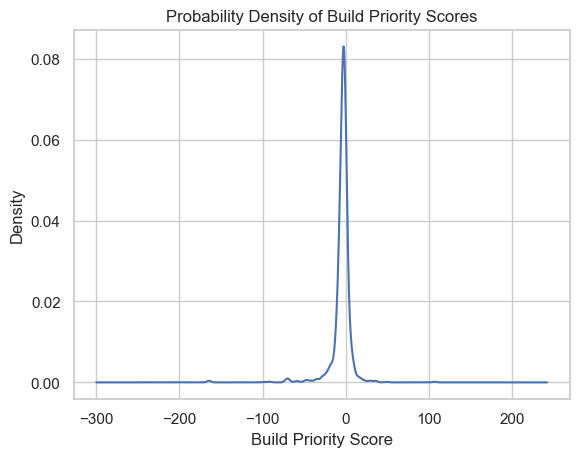

In [654]:
gdf['grid_build_score'].plot(kind='kde')
plt.title('Probability Density of Build Priority Scores')
plt.xlabel('Build Priority Score')
plt.ylabel('Density')
plt.show()

<Axes: ylabel='Density'>

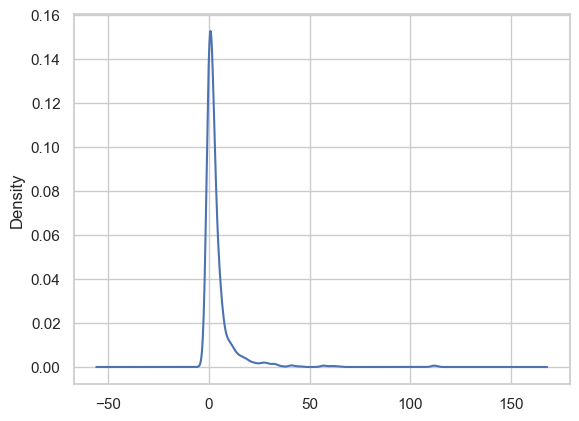

In [655]:
gdf['POI_SCORE'].plot(kind='kde')

In [656]:
gdf['POI_SCORE'].median()

np.float64(2.0)

In [666]:
gdf['POI_SCORE'].mean()

np.float64(3.9962302450340728)

In [667]:
print('median for best spots', gdf[['geoid', 'grid_build_score','POI_SCORE']].drop_duplicates().nlargest(20, 'grid_build_score')['POI_SCORE'].median())
print('mean for best spots', gdf[['geoid', 'grid_build_score','POI_SCORE']].drop_duplicates().nlargest(20, 'grid_build_score')['POI_SCORE'].mean())

median for best spots 0.5
mean for best spots 2.35


In [659]:
gdf['good_spot_to_build'] = None
gdf['good_spot_to_build'] = gdf['good_spot_to_build'].fillna(0)
for i, row in enumerate(gdf[['geoid', 'grid_build_score','POI_SCORE']].drop_duplicates().nlargest(50, 'grid_build_score').iterrows()):
    row = row[1]
    if row['POI_SCORE'] > 0:
        gdf.loc[gdf['geoid'] == row['geoid'], 'good_spot_to_build'] = 1

/var/folders/ff/05grcg517lbgzyz6gz1m5x2c0000gq/T/ipykernel_79658/1979684845.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gdf['good_spot_to_build'] = gdf['good_spot_to_build'].fillna(0)


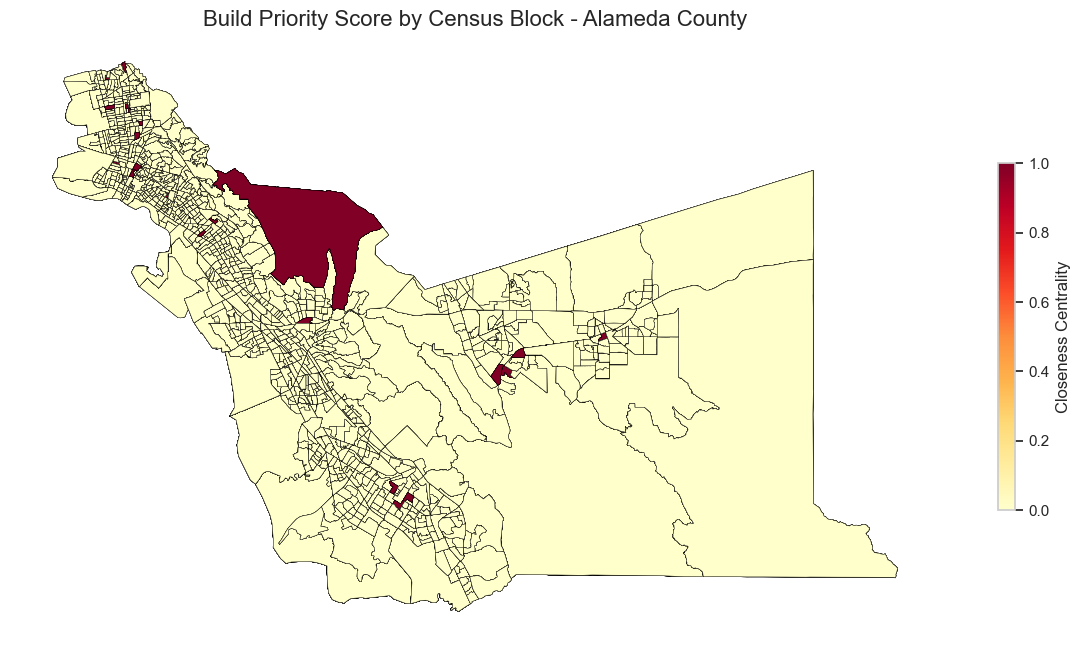

Centrality Statistics:
Mean: -4.5943
Median: -3.0134
Min: -164.3618
Max: 106.5985


In [665]:
fig, ax = plt.subplots(figsize=(15, 9))

gdf.plot(
    ax=ax,
    column='good_spot_to_build',
    cmap='YlOrRd',  # or 'viridis', 'plasma', 'coolwarm'
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={
        'label': 'Closeness Centrality',
        'orientation': 'vertical',
        'shrink': 0.5
    }
)


plt.title('Build Priority Score by Census Block - Alameda County', fontsize=16)
plt.axis('off')
# plt.tight_layout()
plt.show()

# Optional: Print statistics
print(f"Centrality Statistics:")
print(f"Mean: {gdf['grid_build_score'].mean():.4f}")
print(f"Median: {gdf['grid_build_score'].median():.4f}")
print(f"Min: {gdf['grid_build_score'].min():.4f}")
print(f"Max: {gdf['grid_build_score'].max():.4f}")

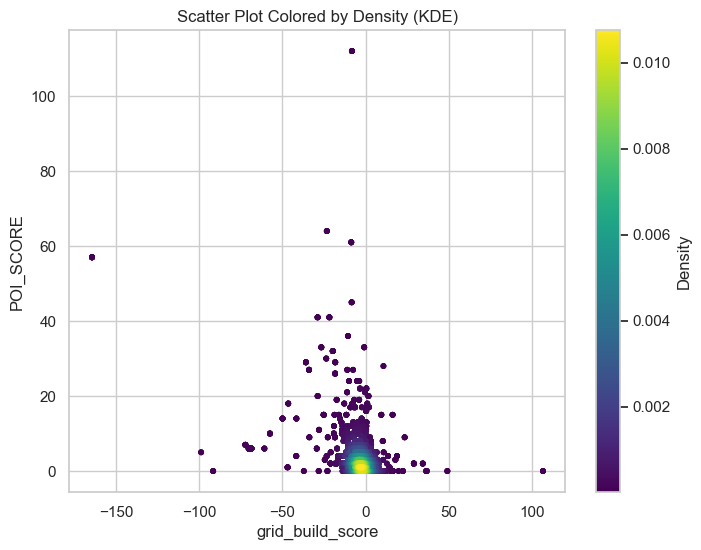

In [533]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

x = gdf['grid_build_score']
y = gdf['POI_SCORE']

# Calculate the point density
xy = np.vstack([x,y])
z = gaussian_kde(xy)(xy)

# Sort the points by density so the densest points are on top
idx = z.argsort()
x_sorted, y_sorted, z_sorted = x.iloc[idx], y.iloc[idx], z[idx]

plt.figure(figsize=(8, 6))
# Plot the scatter with color determined by density (z)
plt.scatter(x_sorted, y_sorted, c=z_sorted, s=10, cmap='viridis') # Adjust marker size (s) as needed
plt.colorbar(label='Density')
plt.xlabel('grid_build_score')
plt.ylabel('POI_SCORE')
plt.title('Scatter Plot Colored by Density (KDE)')
plt.show()


# Adoption Rate Analysis

In [538]:
from sympy import symbols, exp, solve

# Define symbols
t, m, p, q, y = symbols('t m p q y')

# Define the equation
equation = y - m * (1 - exp(-(p + q)*t)) / (1 + (q/p) * exp(-(p + q)*t))

# Solve for q symbolically
m_solutions = solve(equation, m)

# Then substitute your values
t_val, p_val, y_val, q_val = 10,  0.0015, 207, 0.290
numerical_solutions = [sol.subs({t: t_val, q: q_val, p: p_val, y: y_val}) 
                       for sol in m_solutions]
print(numerical_solutions)
m_val = numerical_solutions[0]

[2512.42910723638]


In [539]:
y_solutions = solve(equation, y)
ev_adoption = []
for i in range(0,10):
    t_val = i + 1
    numerical_solutions = [sol.subs({t: t_val, m: m_val, q: q_val, p: p_val}) 
                           for sol in y_solutions]
    print(f"At time {t_val}, EV Adoption: {numerical_solutions[0]}")
    ev_adoption.append(numerical_solutions[0])

At time 1, EV Adoption: 4.36781627298889
At time 2, EV Adoption: 10.1901376105715
At time 3, EV Adoption: 17.9407558685238
At time 4, EV Adoption: 28.2396151804355
At time 5, EV Adoption: 41.8916044294669
At time 6, EV Adoption: 59.9307838361008
At time 7, EV Adoption: 83.6667650170049
At time 8, EV Adoption: 114.725997382602
At time 9, EV Adoption: 155.074503032827
At time 10, EV Adoption: 207.000000000000


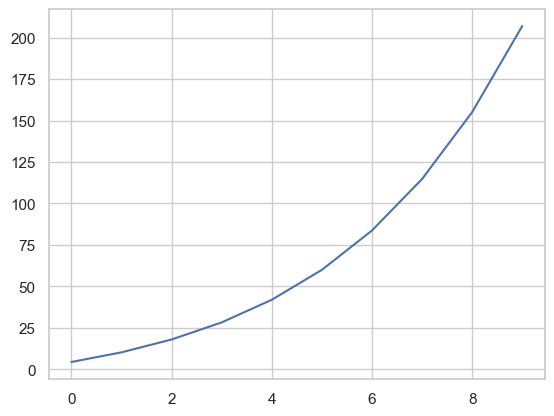

In [540]:
plt.plot(ev_adoption)

In [541]:
import pytidycensus 
import os 
os.environ["CENSUS_API_KEY"] = "576fa283036ef8d4d58d89379a346607f1db9fb1"


In [542]:
df

,geoid_str_,INTPTLAT,INTPTLON,NEIGHBOURS,origin_chargers,destination_chargers,origin_demand_(kW),destination_demand_(kW),distance_km,geoid,neighbor_geoid,POI_SCORE,total_ev_load,IC_min_kW,base_load_kW,overload
0,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"1 (Tract 4233, Alameda, CA)",[333026],None,568.288007,274.272001,0.760447,060014232002,060014233001,0.0,568.288007,287.213688,58.765645,281.074320
1,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"4 (Tract 4231, Alameda, CA)",[333026],None,568.288007,433.504001,0.668007,060014232002,060014231004,0.0,568.288007,287.213688,58.765645,281.074320
2,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"1 (Tract 4220, Alameda, CA)",[333026],"[161015, 205385, 220218, 220219, 308753, 32132...",568.288007,2937.020025,0.823073,060014232002,060014220001,0.0,568.288007,287.213688,58.765645,281.074320
3,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"3 (Tract 4231, Alameda, CA)",[333026],None,568.288007,178.240000,0.667594,060014232002,060014231003,0.0,568.288007,287.213688,58.765645,281.074320
4,"2 (Tract 4232, Alameda, CA)",37.862497,-122.293241,"2 (Tract 4231, Alameda, CA)",[333026],None,568.288007,637.020002,0.707463,060014232002,060014231002,0.0,568.288007,287.213688,58.765645,281.074320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7271,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"3 (Tract 4104, Alameda, CA)",None,[312147],490.880003,928.864010,0.667486,060014323001,060014104003,0.0,490.880003,662.279428,1286.491171,-171.399425
7272,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"3 (Tract 4323, Alameda, CA)",None,None,490.880003,1464.864024,0.686872,060014323001,060014323003,0.0,490.880003,662.279428,1286.491171,-171.399425
7273,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"2 (Tract 4323, Alameda, CA)",None,None,490.880003,255.136003,0.319092,060014323001,060014323002,0.0,490.880003,662.279428,1286.491171,-171.399425
7274,"1 (Tract 4323, Alameda, CA)",37.734870,-122.167514,"4 (Tract 4093, Alameda, CA)",None,None,490.880003,335.424005,0.550617,060014323001,060014093004,0.0,490.880003,662.279428,1286.491171,-171.399425


In [543]:
# Variable for Median Household Income: B19013_001E
variable = "B19013_001E"
year = 2023 
census_income_df = pytidycensus.get_acs(
    geography="block group",
    variables=variable,
    state="06", # California
    county="001", # Alameda County
    year=year,
    output="wide"
)

Getting data from the 2019-2023 5-year ACS


In [544]:
census_income_df.rename(columns={
    'B19013_001_moe': 'median_household_income'
}, inplace=True)
gdf = gdf.merge(census_income_df[['GEOID', 'median_household_income']], left_on='geoid', right_on='GEOID', how='left')

In [545]:
gdf.median_household_income.fillna(gdf.median_household_income.mean(), inplace=True)

/var/folders/ff/05grcg517lbgzyz6gz1m5x2c0000gq/T/ipykernel_79658/1357008762.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gdf.median_household_income.fillna(gdf.median_household_income.mean(), inplace=True)
/var/folders/ff/05grcg517lbgzyz6gz1m5x2c0000gq/T/ipykernel_79658/1357008762.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_s

In [546]:
lower_income_threshold = gdf.median_household_income.quantile(0.33)
upper_income_threshold = gdf.median_household_income.quantile(0.66)

adoption_parameters = {'low': {'p': 0.00118, 'q': 0.303},
                       'medium': {'p': 0.00222, 'q': 0.254},
                      'high': {'p': 0.00174, 'q': 0.231}}

In [547]:
def calculate_ev_adoption(df):
    """
    Calculate EV adoption based on household income and predefined parameters.
    
    Parameters:
    df (DataFrame): DataFrame containing 'median_household_income' and 'geoid'.
    
    Returns:
    DataFrame: Updated DataFrame with 'ev_adoption' column.
    """
    def adoption_rate(row):
        if row['median_household_income'] <= lower_income_threshold:
            p, q = adoption_parameters['low']['p'], adoption_parameters['low']['q']
        elif row['median_household_income'] <= upper_income_threshold:
            p, q = adoption_parameters['medium']['p'], adoption_parameters['medium']['q']
        else:
            p, q = adoption_parameters['high']['p'], adoption_parameters['high']['q']
        
        return p,q
    
    ev_adoption = {}
    for index, row in df.iterrows():
        p_val, q_val = adoption_rate(row)

        t_val = 10

        y_val = row['total_ev_load']  # using ev load as proxy for adoption/market size
        # Solve the equation for m
        m_val = [sol.subs({t: t_val, q: q_val, p: p_val, y: y_val}) 
                            for sol in m_solutions][0]
        
        
        y_solutions = solve(equation, y)
        ev_adoption[row['geoid']] = []
        for i in range(0,10):
            t_val = i + 1
            numerical_solutions = [sol.subs({t: t_val, m: m_val, q: q_val, p: p_val}) 
                                for sol in y_solutions]
            ev_adoption[row['geoid']].append(float(numerical_solutions[0]))

    return pd.DataFrame(ev_adoption, index=range(1, 11)).T.rename(columns={i: f'time_{i}' for i in range(1, 11)})

In [548]:
ev_adoption_df = calculate_ev_adoption(gdf)

In [549]:
ev_adoption_df.columns = pd.date_range(start='2025', end='2035', freq='Y')

/var/folders/ff/05grcg517lbgzyz6gz1m5x2c0000gq/T/ipykernel_79658/1186131789.py:1: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  ev_adoption_df.columns = pd.date_range(start='2025', end='2035', freq='Y')


Text(0.5, 1.0, 'EV Adoption Projections for Example Census Block Groups')

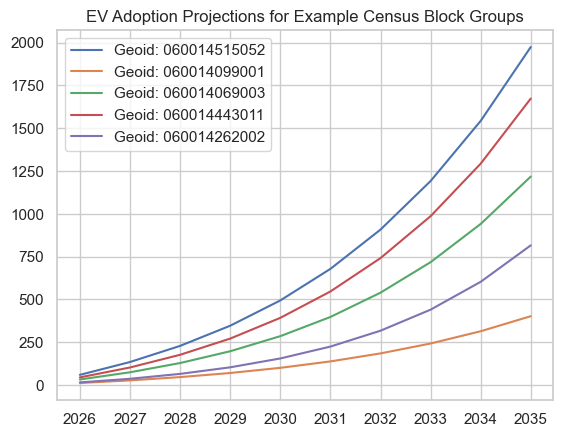

In [669]:
from random import random
for i in range(5):
    ind = np.floor(random() * len(ev_adoption_df))
    plt.plot(ev_adoption_df.iloc[int(ind)], label=f'Geoid: {ev_adoption_df.index[int(ind)]}')

plt.legend()
plt.title('EV Adoption Projections for Example Census Block Groups')

In [552]:
melted_df = pd.melt(
    ev_adoption_df.reset_index().rename(columns={'index': 'geoid'}),
    ignore_index=False,
    id_vars=['geoid'],
    value_vars=ev_adoption_df.columns,
    var_name='Time_Step',
    value_name='year_ev_load',
    
)

melted_df

,geoid,Time_Step,year_ev_load
0,060014232002,2025-12-31 00:00:00,10.899323
1,060014043002,2025-12-31 00:00:00,13.758958
2,060014062022,2025-12-31 00:00:00,16.633298
3,060014327003,2025-12-31 00:00:00,31.034792
4,060014415232,2025-12-31 00:00:00,14.342854
...,...,...,...
1069,060014218001,2034-12-31 00:00:00,607.680010
1070,060014301021,2034-12-31 00:00:00,1989.624012
1071,060014202003,2034-12-31 00:00:00,462.016004
1072,060014203011,2034-12-31 00:00:00,914.016006


In [553]:
# coming up with a dataframe for analysis over time 
tracking_overload_df = gdf.copy()

In [554]:
tracking_overload_df = tracking_overload_df.drop_duplicates(subset=['geoid','neighbor_geoid'])

In [555]:
tracking_overload_df = tracking_overload_df.merge(melted_df, left_on='geoid', right_on='geoid', how='outer')
tracking_overload_df['overload'] = tracking_overload_df['total_ev_load'] - tracking_overload_df['IC_min_kW']
tracking_overload_df['year_overload'] = tracking_overload_df['year_ev_load'] - tracking_overload_df['IC_min_kW']

In [556]:
tracking_overload_df['year_min_overload'] = tracking_overload_df.groupby('Time_Step')['year_overload'].transform('min')
tracking_overload_df['year_max_overload'] = tracking_overload_df.groupby('Time_Step')['year_overload'].transform('max')

In [557]:
tracking_overload_df.groupby('Time_Step').get_group('2034-12-31')['year_overload'].min()

np.float64(-22333.620933056558)

<Axes: ylabel='Density'>

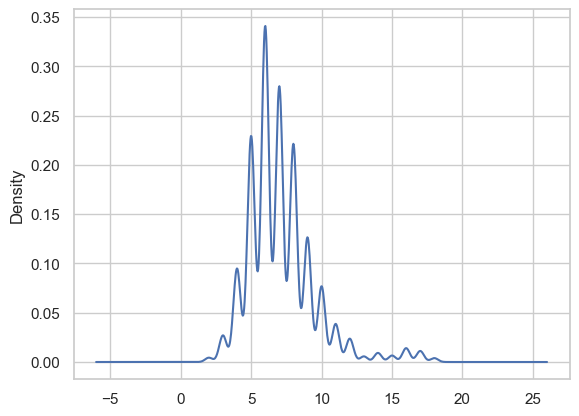

In [558]:
tracking_overload_df.degree.plot(kind='kde')

In [559]:
# trying max minus
# tracking_overload_df['year_transfer_metric'] = ((tracking_overload_df['year_overload'] / (tracking_overload_df['degree'] * tracking_overload_df['distance_km'])) - tracking_overload_df['year_min_overload']) / 10**3 
tracking_overload_df['year_transfer_metric'] = ( tracking_overload_df['year_max_overload'] - (tracking_overload_df['year_overload'] / (tracking_overload_df['degree'] * tracking_overload_df['distance_km']))) / 10**3
# closeness_df = tracking_overload_df.dropna(subset=['year_transfer_metric'])

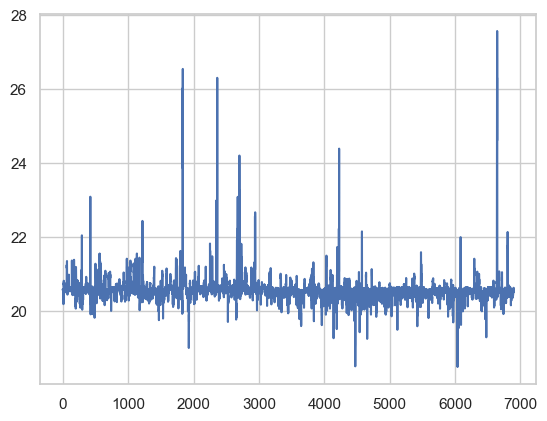

In [560]:
plt.plot(tracking_overload_df.groupby('Time_Step').get_group('2034-12-31').sort_values(by = 'geoid')['year_transfer_metric'].values)

In [561]:
tracking_overload_df.groupby('Time_Step').get_group('2034-12-31').sort_values(by = 'geoid')['year_transfer_metric'].values

array([20.58407607, 20.56071321, 20.57498398, ..., 20.58274621,
       20.49424174, 20.62343934], shape=(6897,))

In [562]:
build_scores = []
for group, closeness_df_group in tracking_overload_df.reset_index().groupby('Time_Step'):
    # calculating build score for each year 
    # closeness_df_group['year_transfer_metric'] = ((closeness_df_group['year_overload'] / (closeness_df_group['degree'] * closeness_df_group['distance_km'])) - closeness_df_group['year_min_overload']) / 10**3 
    G = nx.Graph()
    for _, row in closeness_df_group.iterrows():
        G.add_edge(
            row['geoid'],
            row['neighbor_geoid'],
            weight=row['year_transfer_metric']
        )

    # Calculate closeness centrality
    closeness = nx.closeness_centrality(G, distance='weight', wf_improved=True)

    # Convert to dataframe
    closeness_centrality_df = pd.DataFrame(list(closeness.items()), 
                                columns=['geoid', 'year_closeness_centrality'])
    
    closeness_centrality_df = closeness_centrality_df.merge(
        closeness_df_group[['geoid', 'Time_Step','index']],
        on='geoid',
        how='left'
    )
    build_scores.append(closeness_centrality_df)
    

<Axes: ylabel='Density'>

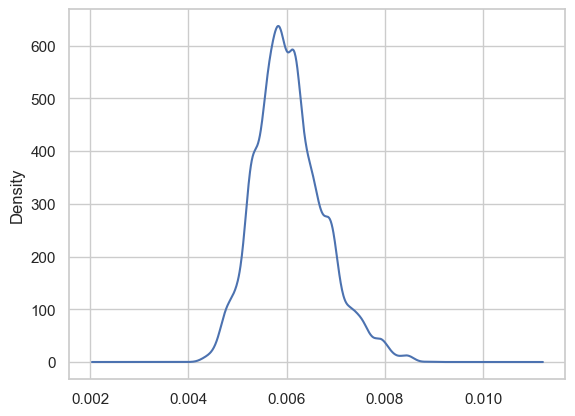

In [563]:
build_scores[-1]['year_closeness_centrality'].plot(kind='kde')

<Axes: ylabel='Density'>

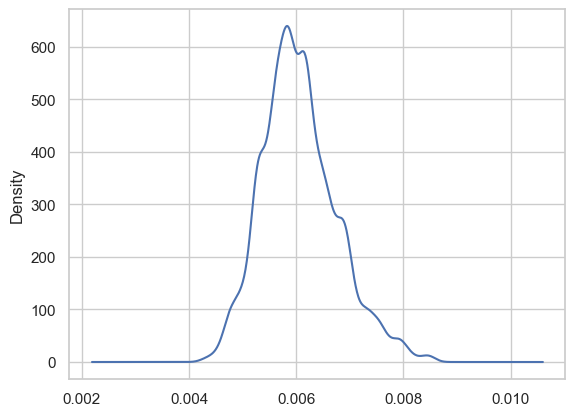

In [564]:
gdf['closeness_centrality'].plot(kind='kde')

In [565]:
build_scores_df = pd.concat(build_scores).drop_duplicates(subset=['Time_Step', 'geoid'])

In [566]:
build_scores_df['year_closeness_centrality'] = build_scores_df['year_closeness_centrality'].astype(float)

In [567]:
build_scores_df.sort_values(['geoid', 'Time_Step'], inplace=True)
closeness_df = build_scores_df.merge(tracking_overload_df, left_on=['geoid','Time_Step'], right_on=['geoid','Time_Step'], how='left')

In [568]:
closeness_df['year_closeness_centrality'] = closeness_df['year_closeness_centrality'].astype(float)

In [569]:
closeness_df.dropna(subset=['year_closeness_centrality'], inplace=True)

In [570]:

closeness_df['year_grid_build_score'] =  - closeness_df['year_overload'] / 10**3 / closeness_df['year_closeness_centrality']


<Axes: ylabel='Density'>

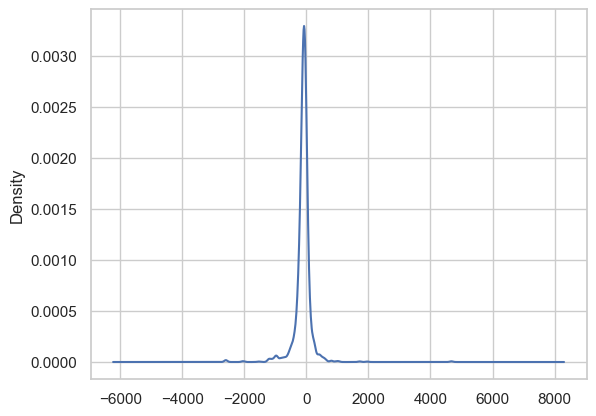

In [571]:
closeness_df.groupby('Time_Step').get_group('2034-12-31')['year_grid_build_score'].plot(kind='kde')

In [572]:
yearly_overload_kepler_df = closeness_df.drop(['neighbor_geoid', 'distance_km'], axis=1).drop_duplicates(subset =['geoid', 'Time_Step']).dropna(subset=['year_grid_build_score'])

{'whiskers': [<matplotlib.lines.Line2D at 0x3ca8cad50>,
 'caps': [<matplotlib.lines.Line2D at 0x3ca8caa90>,
 'boxes': [<matplotlib.lines.Line2D at 0x3ca8c94d0>],
 'medians': [<matplotlib.lines.Line2D at 0x3ca8cab90>],
 'fliers': [<matplotlib.lines.Line2D at 0x3ca561850>],
 'means': []}

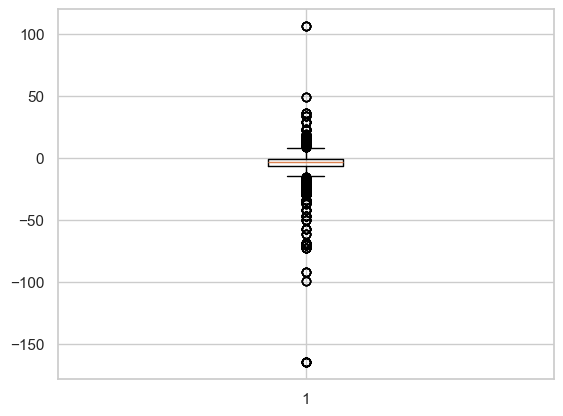

In [573]:
plt.boxplot(gdf['grid_build_score'])

{'whiskers': [<matplotlib.lines.Line2D at 0x3cb792e10>,
 'caps': [<matplotlib.lines.Line2D at 0x3ca6b5f50>,
 'boxes': [<matplotlib.lines.Line2D at 0x3cb23a3d0>],
 'medians': [<matplotlib.lines.Line2D at 0x3ca6b5250>],
 'fliers': [<matplotlib.lines.Line2D at 0x3ca6b79d0>],
 'means': []}

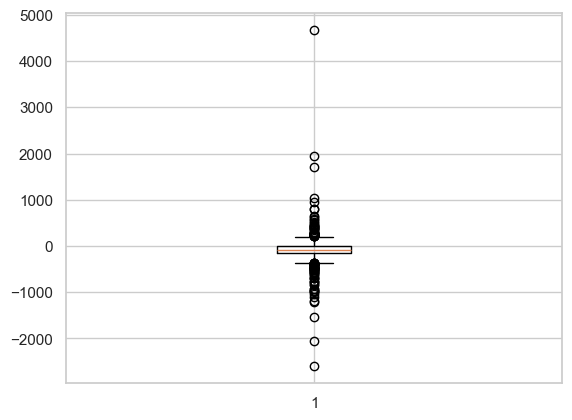

In [574]:
plt.boxplot(yearly_overload_kepler_df.groupby('Time_Step').get_group('2034-12-31')['year_grid_build_score'])

In [575]:
# Create map
map_1 = KeplerGl(height=600)

# Add your data
map_1.add_data(data=yearly_overload_kepler_df, name='census_blocks')

User Guide: https://docs.kepler.gl/docs/keplergl-jupyter


In [576]:
map_1

TypeError: Object of type ndarray is not JSON serializable

KeplerGl(data={'census_blocks': {'index': [0, 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, 85, 90, 95, 100, 105, 110…

In [577]:
# # Save the configuration to a JSON file
# kepler_config = map_1.config
# with open('keplergl_animation.json', 'w') as f:
#     json.dump(kepler_config, f, indent=4)


In [578]:
gdf.to_csv('ev-feeder-census-data.csv')

In [579]:
yearly_overload_kepler_df.to_csv('ev-adoption-data.csv')

/var/folders/ff/05grcg517lbgzyz6gz1m5x2c0000gq/T/ipykernel_79658/718001327.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('Blues')(np.linspace(0.3, 0.9, n_plots))[::-1]


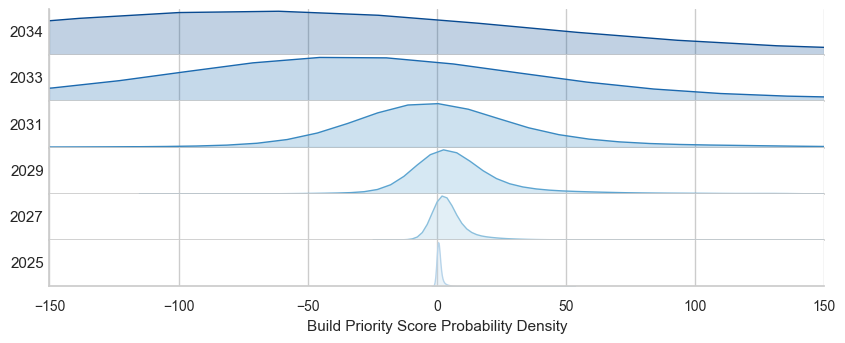

<Figure size 640x480 with 0 Axes>

In [ ]:
# Get unique years and select every other one
all_years = sorted(yearly_overload_kepler_df['Time_Step'].unique())
selected_years = [all_years[-1]] + all_years[::2][::-1]  # Every other year, reversed, plus last year

# Create figure with subplots stacked vertically
n_plots = len(selected_years)
fig, axes = plt.subplots(n_plots, 1, figsize=(10, 0.6*n_plots), 
                         sharex=True)

# Remove spacing between subplots
plt.subplots_adjust(hspace=0)

# If only one plot, axes won't be an array
if n_plots == 1:
    axes = [axes]

# Create a color gradient from light to dark blue
colors = cm.get_cmap('Blues')(np.linspace(0.3, 0.9, n_plots))[::-1]

# Plot each year in its own subplot
for idx, year in enumerate(selected_years):
    ax = axes[idx]
    year_data = yearly_overload_kepler_df[yearly_overload_kepler_df['Time_Step'] == year]
    
    sns.kdeplot(data=year_data, x='year_grid_build_score', fill=True, ax=ax, color=colors[idx])
    ax.set_ylabel(f'{year.strftime("%Y")}', rotation=0, ha='right', va='center', fontsize=11)
    ax.set_xlabel('')
    
    # Remove y-ticks
    ax.set_yticks([])
    
    # Remove x-tick labels except for bottom plot
    if idx < n_plots - 1:
        # ax.set_xticklabels([])
        ax.tick_params(labelbottom=False)
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set x-axis limits to focus on the peak
axes[0].set_xlim(-150,150)  # Adjust this range as needed
axes[-1].tick_params(labelbottom=True, labelsize = 10)
# Add x-label only to bottom plot
axes[-1].set_xlabel('Build Priority Score Probability Density', fontsize=11)

plt.show()
plt.savefig('build-priority-score-evolution-kde.png')